In [9]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/cwru"

import os, glob
print("DATA_ROOT =", DATA_ROOT)
print("Top-level listing:", os.listdir(os.path.dirname(DATA_ROOT)) if os.path.exists(os.path.dirname(DATA_ROOT)) else "parent not found")

for sub in ["normal","inner","outer"]:
    p = os.path.join(DATA_ROOT, sub)
    print(sub, "exists?", os.path.exists(p), " | files:", len(glob.glob(os.path.join(p, "*.mat"))))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT = /content/drive/MyDrive/cwru
Top-level listing: ['Colab Notebooks', 'smartphone_qa_dataset_v2.jsonl', 'Untitled spreadsheet.gsheet', 'Google AI Studio', 'Pu_dataset.zip', 'cwru', 'crwu']
normal exists? True  | files: 4
inner exists? True  | files: 16
outer exists? True  | files: 12


In [10]:
import os, glob, shutil, math
import numpy as np
import scipy.io as sio
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

np.random.seed(42)
tf.random.set_seed(42)

# Parameters
SEGMENT_LENGTH = 2048       # samples per segment
SAMPLE_RATE = 12000         # Hz (CWRU 12k)
NPERSEG = 256
NOVERLAP = 128

IMG_NFREQ = 129
IMG_NTIME = None
NUM_CLASSES = 3

CLASS_MAP = {0:"normal", 1:"inner", 2:"outer"}
CLASS_NAMES = ["Normal","Inner","Outer"]
print("Config set. SEGMENT_LENGTH:", SEGMENT_LENGTH, "SAMPLE_RATE:", SAMPLE_RATE)


Config set. SEGMENT_LENGTH: 2048 SAMPLE_RATE: 12000


In [11]:
def load_drive_end_signal(mat_path, min_len=500):
    """
    Prefer keys that end with '_DE_time' or contain 'DE_time'.
    Fallback: return the longest 1D numeric array inside the .mat
    """
    m = sio.loadmat(mat_path, struct_as_record=False, squeeze_me=True)
    keys = [k for k in m.keys() if not k.startswith("__")]

    for k in keys:
        k_low = k.lower()
        if "de_time" in k_low or k_low.endswith("_de") or "_de_" in k_low:
            arr = np.array(m[k]).squeeze()
            if arr.ndim == 1 and arr.size >= min_len and np.issubdtype(arr.dtype, np.number):
                return arr.astype(np.float32)

    candidates = []
    def recurse(val, name="root"):
        try:
            a = np.array(val).squeeze()
            if isinstance(a, np.ndarray) and a.ndim == 1 and np.issubdtype(a.dtype, np.number):
                candidates.append((name, a.astype(np.float32)))
        except Exception:
            pass

        try:
            if hasattr(val, "__dict__"):
                for subk, subv in val.__dict__.items():
                    recurse(subv, f"{name}.{subk}")
        except Exception:
            pass

        try:
            if isinstance(val, dict):
                for subk, subv in val.items():
                    recurse(subv, f"{name}['{subk}']")
        except Exception:
            pass

        try:
            if isinstance(val, (list, tuple)):
                for i, subv in enumerate(val):
                    recurse(subv, f"{name}[{i}]")
        except Exception:
            pass

    for k in keys:
        recurse(m[k], k)

    if not candidates:
        raise ValueError(f"No 1D numeric array found in {mat_path}")


    candidates.sort(key=lambda x: x[1].size, reverse=True)
    name, arr = candidates[0]
    if arr.size < min_len:
        raise ValueError(f"No 1D candidate >= {min_len} samples found in {mat_path} (best: {name} len {arr.size})")
    print(f"Selected signal {name} (len={arr.size}) from {os.path.basename(mat_path)}")
    return arr


In [12]:
def segment_signal(sig, seg_len=SEGMENT_LENGTH):
    n = len(sig) // seg_len
    if n == 0:
        return np.empty((0, seg_len), dtype=np.float32)
    trimmed = sig[:n*seg_len]
    return trimmed.reshape(n, seg_len)

DATA_ROOT = "/content/drive/MyDrive/cwru"  # ensure this matches your Drive path
X_segments = []
y_segments = []

for label, folder in CLASS_MAP.items():
    folder_path = os.path.join(DATA_ROOT, folder)
    mat_files = sorted(glob.glob(os.path.join(folder_path, "*.mat")))
    print(f"\nClass {label} ({folder}): found {len(mat_files)} files")
    for fpath in mat_files:
        try:
            sig = load_drive_end_signal(fpath, min_len=1000)
        except Exception as e:
            print("  Skipping", os.path.basename(fpath), "| Reason:", e)
            continue
        segs = segment_signal(sig, SEGMENT_LENGTH)
        if segs.shape[0] == 0:
            print("  Skipping (too short):", os.path.basename(fpath), "len", len(sig))
            continue
        for seg in segs:
            X_segments.append(seg)
            y_segments.append(label)

if not X_segments:
    raise RuntimeError("No segments created. Check DATA_ROOT and files.")

X_1d = np.vstack([s[np.newaxis,:] for s in X_segments])  # (N, SEGMENT_LENGTH)
y = np.array(y_segments, dtype=np.int32)

print("\nFinal X_1d shape:", X_1d.shape)
print("Label counts:", {int(c): int(np.sum(y==c)) for c in np.unique(y)})



Class 0 (normal): found 4 files

Class 1 (inner): found 16 files

Class 2 (outer): found 12 files

Final X_1d shape: (2480, 2048)
Label counts: {0: 828, 1: 944, 2: 708}


In [13]:
def make_log_spectrogram(seg, fs=SAMPLE_RATE, nperseg=NPERSEG, noverlap=NOVERLAP):
    f, t, Sxx = spectrogram(seg, fs=fs, nperseg=nperseg, noverlap=noverlap)
    Sxx = np.log(Sxx + 1e-10)  # log scale
    return Sxx.astype(np.float32)  # shape (freq_bins, time_frames)


imgs = []
for i in range(X_1d.shape[0]):
    spec = make_log_spectrogram(X_1d[i])

    if i == 0:
        base_shape = spec.shape
        print("Spectrogram shape (freq,time) per segment:", base_shape)

    spec = spec[..., np.newaxis]
    imgs.append(spec)

X_img = np.stack(imgs, axis=0)  # (N, F, T, 1)
print("Raw X_img shape:", X_img.shape)


def normalize_img(img):
    mn = img.min()
    mx = img.max()
    if mx > mn:
        return (img - mn) / (mx - mn)
    else:
        return np.zeros_like(img)

X_img = np.stack([normalize_img(im) for im in X_img], axis=0)
mean = X_img.mean()
std = X_img.std() + 1e-8
X_img = (X_img - mean) / std
print("Final X_img shape (N,F,T,1):", X_img.shape, "global mean/std:", round(mean,4), round(std,4))


Spectrogram shape (freq,time) per segment: (129, 15)
Raw X_img shape: (2480, 129, 15, 1)
Final X_img shape (N,F,T,1): (2480, 129, 15, 1) global mean/std: 0.4975 0.2437


In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_img, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape,   y_val.shape)
print("Test :", X_test.shape,  y_test.shape)

input_shape = X_train.shape[1:]  # (F, T, 1)
print("Input shape for model:", input_shape)


Train: (1736, 129, 15, 1) (1736,)
Val  : (372, 129, 15, 1) (372,)
Test : (372, 129, 15, 1) (372,)
Input shape for model: (129, 15, 1)


In [15]:
def create_cnn2d(input_shape, n_classes=NUM_CLASSES):
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))

    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())

    model.add(MaxPooling2D((2,1)))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])
    return model

model = create_cnn2d(input_shape, NUM_CLASSES)
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 129, 15, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 129, 15, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 7, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 7, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 3, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 3, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 1, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 1, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 1, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915,075 (3.49 MB)

 Trainable params: 914,115 (3.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
EPOCHS = 40
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 19s 255ms/step - accuracy: 0.8599 - loss: 0.3582 - val_accuracy: 0.6425 - val_loss: 0.9512
Epoch 2/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 491ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.6398 - val_loss: 0.8467
Epoch 3/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 26s 225ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.5887 - val_loss: 0.6765
Epoch 4/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 26s 336ms/step - accuracy: 0.9992 - loss: 0.0017 - val_accuracy: 0.9946 - val_loss: 0.3663
Epoch 5/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 234ms/step - accuracy: 1.0000 - loss: 8.6350e-05 - val_accuracy: 0.9973 - val_loss: 0.1450
Epoch 6/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 237ms/step - accuracy: 1.0000 - loss: 7.2308e-05 - val_accuracy: 0.9919 - val_loss: 0.0639
Epoch 7/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 14s 258ms/step - accuracy: 1.0000 - loss: 3.5811e-05 - val_accuracy: 1.0000 - val_loss: 0.0163
Epoch 8/40
55/55 ━━━━━━━━━━━━━━━━━━━━ 13s 235ms/step - accuracy: 0.9998 - loss: 3.458

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np


y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)


y_true = y_test
if y_true.ndim > 1:
    y_true = np.argmax(y_test, axis=1)


test_acc = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}\n")


print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix (numbers):\n", cm)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step

Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       124
       Inner       1.00      1.00      1.00       142
       Outer       1.00      1.00      1.00       106

    accuracy                           1.00       372
   macro avg       1.00      1.00      1.00       372
weighted avg       1.00      1.00      1.00       372


Confusion Matrix (numbers):
 [[124   0   0]
 [  0 142   0]
 [  0   0 106]]


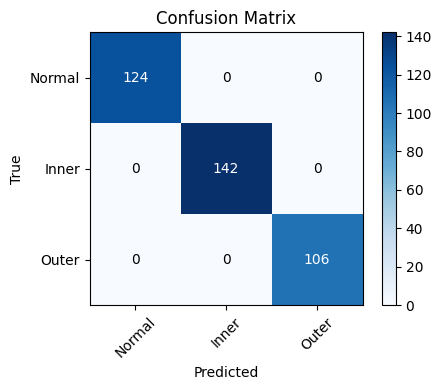

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)

th = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color="white" if cm[i,j] > th else "black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


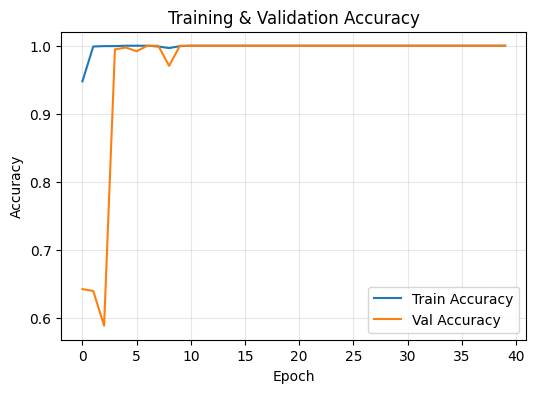

In [21]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history.get('val_accuracy')

plt.figure(figsize=(6,4))
plt.plot(acc, label='Train Accuracy')
if val_acc:
    plt.plot(val_acc, label='Val Accuracy')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


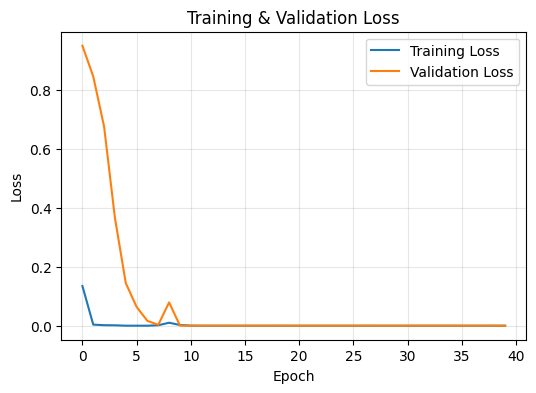

In [22]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history.get('val_loss')

plt.figure(figsize=(6,4))
plt.plot(loss, label='Training Loss')
if val_loss:
    plt.plot(val_loss, label='Validation Loss')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


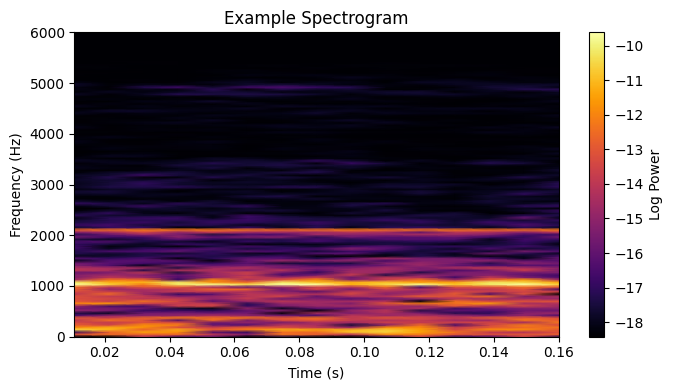

In [23]:
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
import numpy as np

seg = X_1d[0]

f, t, Sxx = spectrogram(seg, fs=SAMPLE_RATE, nperseg=NPERSEG, noverlap=NOVERLAP)

plt.figure(figsize=(7,4))
plt.pcolormesh(t, f, np.log(Sxx + 1e-8), shading='gouraud', cmap='inferno')
plt.title("Example Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label='Log Power')
plt.tight_layout()
plt.show()
